# Исследование данных о ДТП

**Контекст**: «Карты ДТП» — некоммерческий проект, посвящённый проблеме дорожно-транспортных происшествий в России. Цель проекта — повысить безопасность на дорогах.

«Карта ДТП» помогает выявлять реальные причины ДТП, оценивать уровень развития инфраструктуры, а также разрабатывать качественные решения и программы по повышению безопасности на улицах и дорогах. 

Заказчик хочет собирать данные более высокого качества и ожидает от вас рекомендаций: на какие проблемы или особенности обратить внимание.

## Цель
Провести предобработку сырых данных и ответить на вопросы: 
- как менялось число ДТП по временным промежуткам;
- различается ли число ДТП для групп водителей с разным стажем.

## Задачи
1. Загрузить данные и познакомиться с ними
2. Проверить типы данных
3. Проверить пропуски
4. Проверить дубликаты
5. Оценить измненение количества ДТП во времени
6. Проверить наличие связи между стажем водителя и количеством ДТП
7. Выводы и рекомендации

## Описание данных

В проекте используются данные о ДТП по двум регионам: Кировская и Московская области. Для каждого региона есть три датасета, которые связываются между собой по идентификатору ДТП `id`.

### 1. Информация о ДТП

| Столбец | Описание |
|---|---|
| `geometry.coordinates` | координаты ДТП |
| `id` | идентификатор ДТП |
| `properties.tags` | тег происшествия |
| `properties.light` | освещённость |
| `properties.point.lat` | широта |
| `properties.point.long` | долгота |
| `properties.nearby` | ближайшие объекты |
| `properties.region` | регион |
| `properties.scheme` | схема ДТП |
| `properties.address` | ближайший адрес |
| `properties.weather` | погода |
| `properties.category` | категория ДТП |
| `properties.datetime` | дата и время ДТП |
| `properties.injured_count` | число пострадавших |
| `properties.parent_region` | область |
| `properties.road_conditions` | состояние покрытия |
| `properties.participants_count` | число участников |
| `properties.participant_categories` | категории участников |

### 2. Участники ДТП

| Столбец | Описание |
|---|---|
| `role` | роль участника |
| `gender` | пол |
| `violations` | какие правила дорожного движения были нарушены конкретным участником |
| `health_status` | состояние здоровья после ДТП |
| `years_of_driving_experience` | число лет опыта вождения |
| `id` | идентификатор ДТП |

### 3. Транспортные средства

| Столбец | Описание |
|---|---|
| `year` | год выпуска |
| `brand` | марка транспортного средства |
| `color` | цвет |
| `model` | модель |
| `category` | категория |
| `id` | идентификатор ДТП |

## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Загрузим данные в тетрадку
mo_df = pd.read_csv('..\..\Data (csv)\Файлы. Кейс ДТП\Moscowskaya_oblast.csv')
ko_df = pd.read_csv('..\..\Data (csv)\Файлы. Кейс ДТП\Kirovskaya_oblast.csv')

mo_participants_df = pd.read_csv('..\..\Data (csv)\Файлы. Кейс ДТП\Moscowskaya_oblast_participiants.csv')
ko_participants_df = pd.read_csv('..\..\Data (csv)\Файлы. Кейс ДТП\Kirovskaya_oblast_participiants.csv')

mo_vehicles_df = pd.read_csv('..\..\Data (csv)\Файлы. Кейс ДТП\Moscowskaya_oblast_vehicles.csv')
ko_vehicles_df = pd.read_csv('..\..\Data (csv)\Файлы. Кейс ДТП\Kirovskaya_oblast_vehicles.csv')

Посмотрим на первые строки каждой из таблиц

In [3]:
mo_df.head(3)

,geometry.coordinates,id,properties.tags,properties.light,properties.point.lat,properties.point.long,properties.nearby,properties.region,properties.scheme,properties.address,properties.weather,properties.category,properties.datetime,properties.injured_count,properties.parent_region,properties.road_conditions,properties.participants_count,properties.participant_categories
0,"[37.5253, 55.9992]",2163589,['Дорожно-транспортные происшествия'],Светлое время суток,55.999200,37.525300,"['Мост, эстакада, путепровод', 'Крупный торгов...",Мытищинский,NaN,"ХЛЕБНИКОВО-РОГАЧЕВО, 0 км",['Ясно'],Столкновение,2019-01-31 09:05:00,1,Московская область,"['Мокрое', 'Отсутствие, плохая различимость го...",3,['Все участники']
1,"[37.058966, 55.788688]",2155398,"['Дорожно-транспортные происшествия', 'ДТП и п...","В темное время суток, освещение включено",55.788688,37.058966,[],Истринский,70.0,М-9 Балтия Москва - Волоколамск - граница с Ла...,['Ясно'],Столкновение,2018-09-22 05:00:00,2,Московская область,['Сухое'],4,"['Все участники', 'Дети']"
2,"[37.4419, 56.0081]",2163319,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено",56.008100,37.441900,"['Многоквартирные жилые дома', 'Остановка обще...",Лобня,820.0,"г Лобня, ул Ленина, 43",['Пасмурно'],Наезд на пешехода,2019-01-24 19:30:00,1,Московская область,['Обработанное противогололедными материалами'],2,"['Все участники', 'Пешеходы']"


In [4]:
ko_df.head(3)

,geometry.coordinates,id,properties.tags,properties.light,properties.point.lat,properties.point.long,properties.nearby,properties.region,properties.scheme,properties.address,properties.weather,properties.category,properties.datetime,properties.injured_count,properties.parent_region,properties.road_conditions,properties.participants_count,properties.participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']


In [5]:
mo_participants_df.head(3)

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,[],Не пострадал,13.0,2163589
1,Водитель,Мужской,[],Не пострадал,13.0,2163589
2,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398


In [6]:
ko_participants_df.head(3)

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208


In [7]:
mo_vehicles_df.head(3)

,year,brand,color,model,category,id
0,2012.0,ГАЗ,Белый,Прочие модели ГАЗ,Фургоны,2163589
1,2008.0,OPEL,Черный,Astra,"С-класс (малый средний, компактный) до 4,3 м",2155398
2,2017.0,MAZDA,Черный,CX-5,"В-класс (малый) до 3,9 м",2163319


In [8]:
ko_vehicles_df.head(3)

,year,brand,color,model,category,id
0,2011.0,ВАЗ,Серый,Kalina,"А-класс (особо малый) до 3,5 м",1983180
1,2005.0,CHEVROLET,Зеленый,Niva,"С-класс (малый средний, компактный) до 4,3 м",2889433
2,2017.0,RENAULT,Синий,Logan,"С-класс (малый средний, компактный) до 4,3 м",2591208


Выведем число строк в каждом датафрейме для оценки общего объема данных.

In [9]:
print(f'Информация о ДТП в МО, число строк: {mo_df.shape[0]}', end = '\n')
print(f'Информация о ДТП в КО, число строк: {ko_df.shape[0]}', end = '\n')

print(f'Информация об участниках ДТП в МО, число строк: {mo_participants_df.shape[0]}', end = '\n')
print(f'Информация об участниках ДТП в КО, число строк: {ko_participants_df.shape[0]}', end = '\n')

print(f'Информация о транспортном средстве в МО, число строк: {mo_vehicles_df.shape[0]}', end = '\n')
print(f'Информация о транспортном средстве в KО, число строк: {ko_vehicles_df.shape[0]}', end = '\n')

Информация о ДТП в МО, число строк: 45618
Информация о ДТП в КО, число строк: 14517
Информация об участниках ДТП в МО, число строк: 95177
Информация об участниках ДТП в КО, число строк: 31235
Информация о транспортном средстве в МО, число строк: 65606
Информация о транспортном средстве в KО, число строк: 20093


**Выводы по знакомству с данными:**
- содержание таблиц соответствует описанию;
- датасеты с информацией по КО  примерно в 3 раза меньше, чем в датасеты по МО;
- таблицы имеют пропуски, причем не только в виде NaN, но и в виде заглушек (например, поле violations содержит пустой список '[]')

## 2. Работа с типами данных

### 2.1 Таблицы mo_df и ko_df

Для корректной работы с данными необходимо, чтобы значения в таблицах были в единых типах данных. Проверим это.

In [10]:
mo_df.dtypes

geometry.coordinates                  object
id                                     int64
properties.tags                       object
properties.light                      object
properties.point.lat                 float64
properties.point.long                float64
properties.nearby                     object
properties.region                     object
properties.scheme                    float64
properties.address                    object
properties.weather                    object
properties.category                   object
properties.datetime                   object
properties.injured_count               int64
properties.parent_region              object
properties.road_conditions            object
properties.participants_count          int64
properties.participant_categories     object
dtype: object

Здесь поле properties.datetime следует перевести в тип данных datetime64, остальные данные в корректных типах

In [11]:
# Переведем поле properties.datetime к типу datetime64
mo_df['properties.datetime'] = pd.to_datetime(mo_df['properties.datetime'],errors = 'coerce')

In [12]:
ko_df.dtypes

geometry.coordinates                  object
id                                     int64
properties.tags                       object
properties.light                      object
properties.point.lat                 float64
properties.point.long                float64
properties.nearby                     object
properties.region                     object
properties.scheme                    float64
properties.address                    object
properties.weather                    object
properties.category                   object
properties.datetime                   object
properties.injured_count               int64
properties.parent_region              object
properties.road_conditions            object
properties.participants_count          int64
properties.participant_categories     object
dtype: object

Аналогичная ситуация с таблицей о ДТП в Кировской области

In [13]:
# Переведем поле properties.datetime к типу datetime64
ko_df['properties.datetime'] = pd.to_datetime(ko_df['properties.datetime'],errors = 'coerce')

### 2.2 Таблицы mo_participants_df и ko_participants_df

In [14]:
mo_participants_df.dtypes

role                            object
gender                          object
violations                      object
health_status                   object
years_of_driving_experience    float64
id                               int64
dtype: object

In [15]:
ko_participants_df.dtypes

role                            object
gender                          object
violations                      object
health_status                   object
years_of_driving_experience    float64
id                               int64
dtype: object

Здесь типы данных корректны

### 2.3 Таблицы mo_vehicles_df и ko_vehicles_df

In [16]:
mo_vehicles_df.dtypes

year        float64
brand        object
color        object
model        object
category     object
id            int64
dtype: object

In [17]:
ko_vehicles_df.dtypes

year        float64
brand        object
color        object
model        object
category     object
id            int64
dtype: object

Здесь типы данных также корректны

## 3. Работа с пропусками

### 3.1 Таблицы mo_df и ko_df

In [18]:
# Проверим наличие явных пропусков
round(mo_df.isna().mean()*100,3)

geometry.coordinates                 0.000
id                                   0.000
properties.tags                      0.000
properties.light                     0.000
properties.point.lat                 0.007
properties.point.long                0.007
properties.nearby                    0.000
properties.region                    0.000
properties.scheme                    3.032
properties.address                   3.849
properties.weather                   0.000
properties.category                  0.000
properties.datetime                  0.000
properties.injured_count             0.000
properties.parent_region             0.000
properties.road_conditions           0.000
properties.participants_count        0.000
properties.participant_categories    0.000
dtype: float64

Таблица с информацией о ДТП в МО содержит явные пропуски в полях: properties.point.lat (0.007 %), properties.point.long (0.007 %), properties.scheme (3.032 %), properties.address (3.849 %)

При первичном знакомстве с данными было определено, что некоторые поля содержат значения-заглушки. Проверим датасет на их наличие.

In [19]:
# Создадим список возможных заглушек
fillings_gaps = ['[]',0,'-']
round(mo_df.isin(fillings_gaps).mean() * 100, 3)

geometry.coordinates                  0.000
id                                    0.000
properties.tags                       0.000
properties.light                      0.000
properties.point.lat                  0.000
properties.point.long                 0.000
properties.nearby                    23.173
properties.region                     0.000
properties.scheme                     0.000
properties.address                    0.000
properties.weather                    0.000
properties.category                   0.000
properties.datetime                   0.000
properties.injured_count              0.000
properties.parent_region              0.000
properties.road_conditions            0.000
properties.participants_count         0.000
properties.participant_categories     0.000
dtype: float64

Итак, поле properties.nearby содержит более 23% значений-заглушек

In [20]:
round(ko_df.isna().mean()*100,3)

geometry.coordinates                 0.000
id                                   0.000
properties.tags                      0.000
properties.light                     0.000
properties.point.lat                 0.220
properties.point.long                0.220
properties.nearby                    0.000
properties.region                    0.000
properties.scheme                    7.832
properties.address                   4.643
properties.weather                   0.000
properties.category                  0.000
properties.datetime                  0.000
properties.injured_count             0.000
properties.parent_region             0.000
properties.road_conditions           0.000
properties.participants_count        0.000
properties.participant_categories    0.000
dtype: float64

Таблица с информацией о ДТП в КО содержит пропуски в полях: properties.point.lat (0.22 %), properties.point.long (0.22 %), properties.scheme (7.832 %), properties.address (4.643 %)

Аналогично проверим датасет на наличие заглушек

In [21]:
# Создадим список возможных заглушек
round(ko_df.isin(fillings_gaps).mean() * 100, 3)

geometry.coordinates                  0.000
id                                    0.000
properties.tags                       0.000
properties.light                      0.000
properties.point.lat                  0.000
properties.point.long                 0.000
properties.nearby                    19.928
properties.region                     0.000
properties.scheme                     0.000
properties.address                    0.000
properties.weather                    0.000
properties.category                   0.000
properties.datetime                   0.000
properties.injured_count              0.000
properties.parent_region              0.000
properties.road_conditions            0.000
properties.participants_count         0.000
properties.participant_categories     0.000
dtype: float64

Поле properties.nearby содержит почти 20% значений-заглушек

**Вывод**: Пропуски в данных полях в нашем исследовании не так значимы, поскольку нас интересует количество ДТП, а не их схема,адрес, координаты и ближайшие объекты, поэтому их можно оставить без изменений. В то же время характеристика места происшествия может содержать информацию, связанную с причинностью ДТП, что важно для проекта в целом. Поэтому на данном этапе стоит зафиксировать как рекоммендацию восстановление пропущенных данных для будущего анализа по улучшению инфраструктуры дорог.

### 3.2 Таблицы mo_participants_df и ko_participants_df

In [22]:
round(mo_participants_df.isna().mean()*100,3)

role                            0.000
gender                          1.965
violations                      0.000
health_status                   0.112
years_of_driving_experience    37.297
id                              0.000
dtype: float64

Таблица с участниками ДТП в МО содержит явные пропуски в полях gender (почти 2%), health_status (около 0.1%), years_of_driving_experience (более 37%).

In [23]:
round(ko_participants_df.isna().mean()*100,3)

role                            0.000
gender                          2.715
violations                      0.000
health_status                   0.320
years_of_driving_experience    45.865
id                              0.000
dtype: float64

Таблица с участниками ДТП в KО содержит явные пропуски в полях gender (2.715 %), health_status (0.32%), years_of_driving_experience (почти 36%).

Датафреймы также могут содержать заглушки, проверим.

In [24]:
round(mo_participants_df.isin(fillings_gaps).mean() * 100, 3)

role                            0.000
gender                          0.000
violations                     45.908
health_status                   0.000
years_of_driving_experience     0.000
id                              0.000
dtype: float64

In [25]:
round(ko_participants_df.isin(fillings_gaps).mean() * 100, 3)

role                            0.000
gender                          0.000
violations                     42.725
health_status                   0.000
years_of_driving_experience     0.000
id                              0.000
dtype: float64

Итак, оба датафрейма содержат заглушки пропусков в поле violations в количестве 46% в МО и 42,7 в КО.

In [26]:
# Чтобы определить, почему в поле со стажем так много пропусков, проверим, какие категории хранятся в поле role
ko_participants_df['role'].unique()

array(['Водитель', 'Пассажир', 'Велосипедист', 'Пешеход',
       'Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира'],
      dtype=object)

In [27]:
round(ko_participants_df.loc[ko_participants_df['role'] != 'водитель']['id'].count() / ko_participants_df['id'].count(),2)

np.float64(1.0)

In [28]:
round(mo_participants_df.loc[mo_participants_df['role'] != 'водитель']['id'].count() / mo_participants_df['id'].count(),2)

np.float64(1.0)

Таким образом, пропуски в поле со стажем можно объяснить тем, что строки заполняются также и для не водителей, у которых поле с опытом вождения не заполняется - доля таких строк 0.39 (в МО - 0.36), а общая доля пропусков в поле со стажем 0.46 (в МО - 0.37)

**Вывод**: для обоих областей информация об участниках ДТП содержит явные пропуски в полях со стажем и значения-заглушки в полях с нарушением ПДД, также менее 3% пропусков наблюдаются в поле gender. В данном исследовании типы ДТП нам не важны, поэтому пропуски оставим как есть, но эта информация может быть полезной для исследований причин и условий аварий, например, есть ли связь между условиями зоны ДТП и тем, какие правила ПДД нарушены. Это также стоит отметить для будущих рекомендаций. 

### 3.3 Таблицы mo_vehicles_df и ko_vehicles_df

In [29]:
print(f'явные пропуски в mo_vehicles_df:\n{round(mo_vehicles_df.isna().mean() * 100,3)}')

print(f'наличие пропусков заглушек в mo_vehicles_df:\n{round(mo_vehicles_df.isin(fillings_gaps).mean()*100,3)}')

явные пропуски в mo_vehicles_df:
year        2.661
brand       2.166
color       1.282
model       2.166
category    0.000
id          0.000
dtype: float64
наличие пропусков заглушек в mo_vehicles_df:
year        0.0
brand       0.0
color       0.0
model       0.0
category    0.0
id          0.0
dtype: float64


In [30]:
print(f'явные пропуски в mo_vehicles_df:\n{round(ko_vehicles_df.isna().mean() * 100,3)}')

print(f'наличие пропусков заглушек в mo_vehicles_df:\n{round(ko_vehicles_df.isin(fillings_gaps).mean()*100,3)}')

явные пропуски в mo_vehicles_df:
year        3.952
brand       3.857
color       2.240
model       3.857
category    0.000
id          0.000
dtype: float64
наличие пропусков заглушек в mo_vehicles_df:
year        0.0
brand       0.0
color       0.0
model       0.0
category    0.0
id          0.0
dtype: float64


**Вывод**: в таблицах для обеих областей имеются только явные пропуски в полях year, brand, color, model: для МО эти значения не превышаются 3%, для КО - 4%. Отстутствие информации в данных полях нежелательно с точки зрения целей проекта: год выпуска модели, ее марка могут коррелировать с количеством ДТП, что следует учитывать при разработке превентивных мер по снижению числа аварий. С другой стороны, число пропусков не более 4%, что может не быть значимым при исследованиях. Этот вопрос следует оставить на усмотрение заказчика. Для нашей работы эти пропуски также не важны, поэтому оставим их как есть.

## 4. Проверка на дубликаты

### 4.1 Таблицы mo_df и ko_df

Проверим данные на полные дубликаты

In [31]:
mo_df.duplicated().sum()

np.int64(0)

In [32]:
ko_df.duplicated().sum()

np.int64(0)

Полных дубликатов нет. Проверим на неявные дубликаты: для этого переведем все текстовые значения к snake_case

In [33]:
# Сначала для удобства упростим названия столбцов в датафрейме, удалив слово properties
mo_df.columns = mo_df.columns.str.replace('properties.','')
ko_df.columns = ko_df.columns.str.replace('properties.','')

# Напишем функцию, нормализирующую все категориальные столбцы
def to_snake_case(df):
    cat_cols = df.select_dtypes('object').columns
    for col in cat_cols:
        df[col] = df[col].str.lower().str.strip()
to_snake_case(mo_df)
to_snake_case(ko_df)

print(f'mo_df.columns:\n{mo_df.columns}')

print(f'ko_df.columns:\n{ko_df.columns}')

mo_df.columns:
Index(['geometry.coordinates', 'id', 'tags', 'light', 'point.lat',
       'point.long', 'nearby', 'region', 'scheme', 'address', 'weather',
       'category', 'datetime', 'injured_count', 'parent_region',
       'road_conditions', 'participants_count', 'participant_categories'],
      dtype='object')
ko_df.columns:
Index(['geometry.coordinates', 'id', 'tags', 'light', 'point.lat',
       'point.long', 'nearby', 'region', 'scheme', 'address', 'weather',
       'category', 'datetime', 'injured_count', 'parent_region',
       'road_conditions', 'participants_count', 'participant_categories'],
      dtype='object')


Определить неявные дубликаты можно по наличию дубликатов в поле id.

In [34]:
mo_df['id'].duplicated().sum()

np.int64(0)

In [35]:
ko_df['id'].duplicated().sum()

np.int64(0)

In [36]:
print(f'Число строк в mo_df было: 45618, стало: {mo_df.shape[0]}')
print(f'Число строк в ko_df было: 14517, стало: {ko_df.shape[0]}')

Число строк в mo_df было: 45618, стало: 45618
Число строк в ko_df было: 14517, стало: 14517


**Вывод**: в обоих датафреймах явные и неявные дубликаты отсутствуют.

### 4.2 Таблицы mo_participants_df и ko_participants_df

В датафреймах хранится информация об участниках ДТП, при этом следует учитывать, что в одном и том же ДТП могут участвовать несколько человек. Поэтому полные дубликаты нужно удалить, а неполные - оставить. Но перед этим также стоит перевести категориальные значения к snake_case, поскольку дубликатов может быть больше.

In [37]:
# Переводим данные к snake_case
to_snake_case(mo_participants_df)
to_snake_case(ko_participants_df)

In [38]:
# Проверка на явные дубликаты
print(f'явные дубликаты в mo_participants_df: {mo_participants_df.duplicated().mean():.2%}')
print(f'явные дубликаты в ko_participants_df: {ko_participants_df.duplicated().mean():.2%}')

явные дубликаты в mo_participants_df: 37.22%
явные дубликаты в ko_participants_df: 31.14%


In [39]:
# Проверим неявные дубликаты по полю id:
print(f'неявные дубликаты в mo_participants_df: {mo_participants_df['id'].duplicated().mean():.2%}')
print(f'неявные дубликаты в ko_participants_df: {ko_participants_df['id'].duplicated().mean():.2%}')

неявные дубликаты в mo_participants_df: 59.20%
неявные дубликаты в ko_participants_df: 57.29%


Итак, полные дубликаты удаляем, неполные - фактически допустимы.

In [40]:
# Удаляем полные дубликаты
mo_participants_df.drop_duplicates(inplace = True)
ko_participants_df.drop_duplicates(inplace=True)

In [41]:
print(f'Число строк в mo_participants_df было: 95177, стало: {mo_participants_df.shape[0]}')
print(f'Число строк в ko_participants_df было: 31235, стало: {ko_participants_df.shape[0]}')

Число строк в mo_participants_df было: 95177, стало: 59749
Число строк в ko_participants_df было: 31235, стало: 21508


**Вывод:** в обоих датасетах более 30% полных дубликатов, при этом их фактически быть не должно. Заказчику следует обратить внимание, почему они появились. Возможно, причина техническая или человеческий фактор. Также найдены неявные дубликаты, но они допустимы, поскольку в одной аварии может участвовать несколько человек. 

### 4.3 Таблицы mo_vehicles_df и ko_vehicles_df

In [42]:
# Переведем категориальные данные к snake_case
to_snake_case(mo_vehicles_df)
to_snake_case(ko_vehicles_df)

In [43]:
# Проверка на полные дубликаты
print(f'полные дубликаты в mo_vehicles_df: {mo_vehicles_df.duplicated().mean():.2%}')
print(f'полные дубликаты в ko_vehicles_df: {ko_vehicles_df.duplicated().mean():.2%}')

полные дубликаты в mo_vehicles_df: 1.08%
полные дубликаты в ko_vehicles_df: 0.09%


In [44]:
# Проверка на неявные дубликаты
print(f'неявные дубликаты в mo_vehicles_df: {mo_vehicles_df['id'].duplicated().mean():.2%}')
print(f'неявные дубликаты в ko_vehicles_df: {ko_vehicles_df['id'].duplicated().mean():.2%}')

неявные дубликаты в mo_vehicles_df: 41.14%
неявные дубликаты в ko_vehicles_df: 34.07%


Здесь специфика датасетов позволяет иметь как полные, так и неполные дубликаты. Полные дубликаты допустимы ввиду того, что в аварии могут участвовать совершенно одинаковые машины (что, конечно, маловероятно, не исключать нельзя), неполные дубликаты вполне возможны, поскольку в ДТП  могут участвовать, несколько транспортных средств.

**Вывод:** Наличие дубликатов в данных датасетах маловероятно, но не исключено: может быть так, что в аварию попали совершенно одинаковые машины, поэтому полные дубликаты трогать не будем. Неполные дубликаты также допустимы.

## 5. Изменение количества ДТП во времени

### 5.1 Определим, сколько ДТП случалось в каждый день недели

Сначала определим, за какой временной период предоставлены данные

In [45]:
min_date_mo = pd.to_datetime(mo_df['datetime'].min()).date()
max_date_mo = pd.to_datetime(mo_df['datetime'].max()).date()

min_date_ko = pd.to_datetime(ko_df['datetime'].min()).date()
max_date_ko = pd.to_datetime(ko_df['datetime'].max()).date()

print(f'Временной диапазон данных в df_mo: от {min_date_mo} по {max_date_mo}')
print(f'Временной диапазон данных в df_ko: от {min_date_ko} по {max_date_ko}')

Временной диапазон данных в df_mo: от 2015-01-01 по 2024-09-30
Временной диапазон данных в df_ko: от 2015-01-01 по 2024-08-31


In [46]:
# Для МО
mo_df['day_of_week'] = mo_df['datetime'].dt.day_of_week
week_daily_ra_mo = mo_df.groupby('day_of_week',as_index = False).agg(count_accidents_mo = ('id','count'))

# Для КО
ko_df['day_of_week'] = ko_df['datetime'].dt.day_of_week
week_daily_ra_ko = ko_df.groupby('day_of_week',as_index = False).agg(count_accidents_ko = ('id','count'))                                                                   

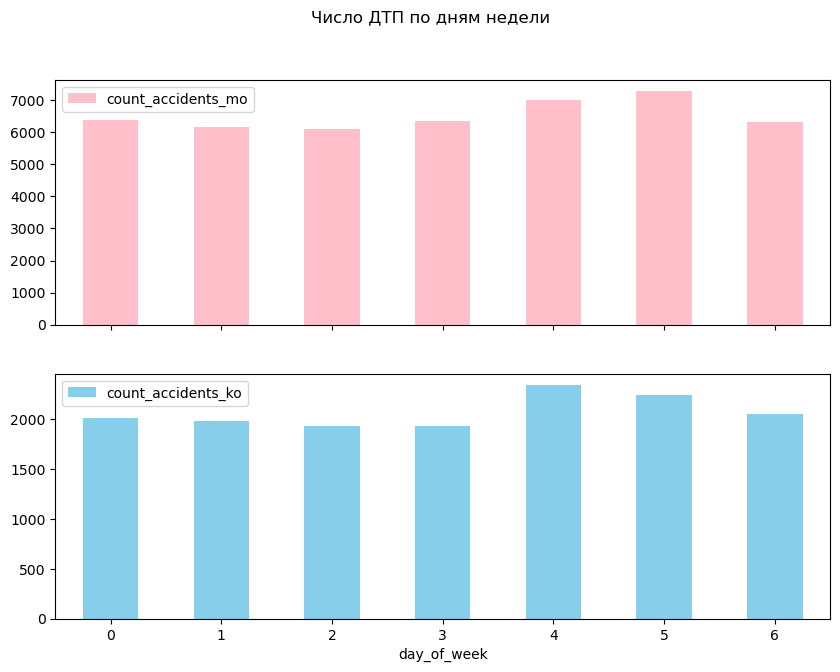

In [47]:
# Объединим полученные таблицы
week_daily_ra = week_daily_ra_mo.merge(week_daily_ra_ko, on = 'day_of_week')

# Визуализируем результаты
ax = week_daily_ra.plot(
    kind='bar',
    subplots=True,
    sharex=True,
    sharey=False,
    legend=True,
    title='Число ДТП по дням недели',
    figsize=(10, 7),
    x='day_of_week',
    rot=0,
    color = ['pink','skyblue']
)

# Убрать заголовок у каждого подграфика
for a in ax:
    a.set_title('')
    a.set_ylabel('')

plt.show()

По диаграмме видно, что в Московской области чаще происходили ДТП в субботу, а в Кировской области - в пятницу. Но разница между пятницей и субботой внутри каждого региона небольшая

### 5.2 Определим число происшествий по месяцам

In [48]:
# Для МО
mo_df['month'] = mo_df['datetime'].dt.month
monthly_ra_mo = mo_df.groupby('month',as_index = False).agg(count_accidents_mo = ('id','count'))

# Для КО
ko_df['month'] = ko_df['datetime'].dt.month
monthly_ra_ko = ko_df.groupby('month',as_index = False).agg(count_accidents_ko = ('id','count'))     

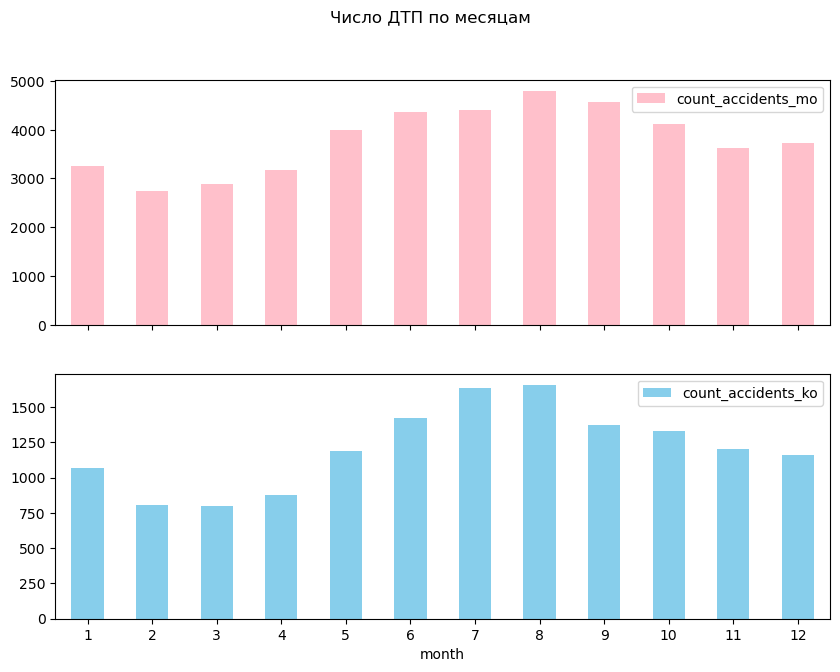

In [49]:
# Объединим полученные таблицы
monthly_ra = monthly_ra_mo.merge(monthly_ra_ko, on = 'month')

# Визуализируем результаты
ax = monthly_ra.plot(
    kind='bar',
    subplots=True,
    sharex=True,
    sharey=False,
    legend=True,
    title='Число ДТП по месяцам',
    figsize=(10, 7),
    x='month',
    rot=0,
    color = ['pink','skyblue']
)

# Убрать заголовок у каждого подграфика
for a in ax:
    a.set_title('')
    a.set_ylabel('')

plt.show()

По диаграмме видно, что чаще всего аварии происходят в августе - это характерно для обоих регионов. Наиболее спокойный месяц - февраль.

## 6. Анализ связи числа ДТП со стажем

### 6.1 Выделим категории водителей по стажу

Условно разобьем данные на категории по 5 лет стажа до 40 лет, и более 40 как отдельную категорию. 

In [50]:
# Категоризируем данные
mo_participants_df['exp_category'] = pd.cut(mo_participants_df['years_of_driving_experience'], [-1,5,10,15,20,25,30,35,40,float('inf')])
ko_participants_df['exp_category'] = pd.cut(ko_participants_df['years_of_driving_experience'], [-1,5,10,15,20,25,30,35,40,float('inf')])

# Посчитаем число аварий для каждоой категории
count_ra_by_exp_mo = mo_participants_df.groupby('exp_category', observed=True).agg(count_accidents = ('id','nunique'))
                                                                   
count_ra_by_exp_ko = ko_participants_df.groupby('exp_category', observed=True).agg(count_accidents = ('id','nunique'))

### 6.2 Определим, существуют ли категории, которые значительно отличаются по числу ДТП

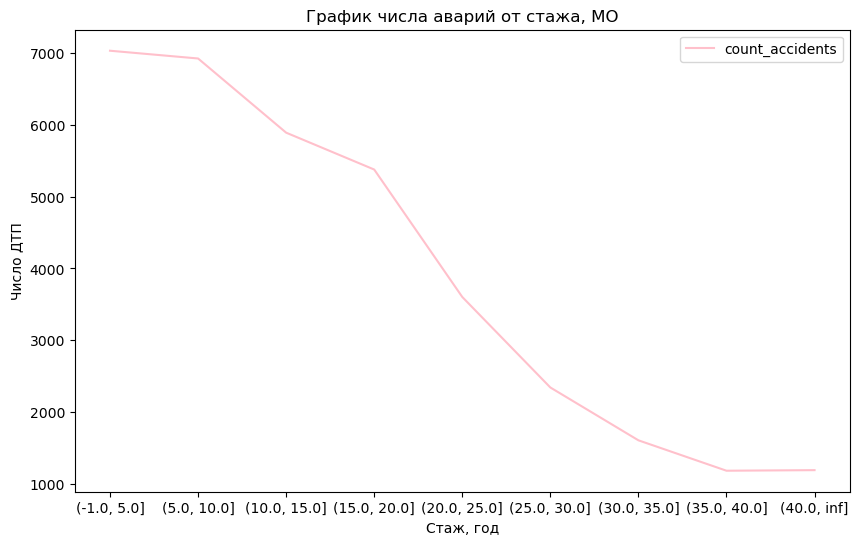

In [51]:
# Построим график для МО
count_ra_by_exp_mo.plot(kind='line',
                       figsize=(10,6),
                       color='pink')
plt.title('График числа аварий от стажа, МО')
plt.ylabel('Число ДТП')
plt.xlabel('Стаж, год')
plt.show()

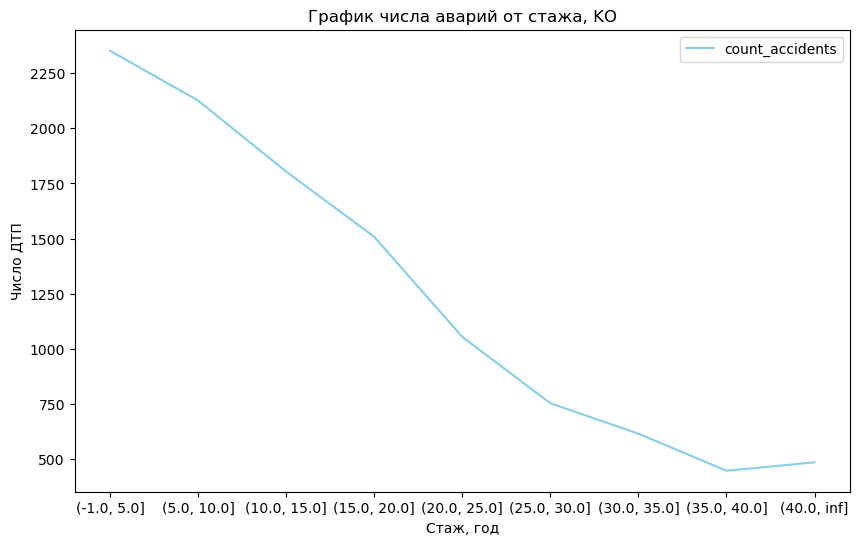

In [52]:
# Построим график для КО
count_ra_by_exp_ko.plot(kind='line',
                       figsize=(10,6),
                       color='skyblue')
plt.title('График числа аварий от стажа, KО')
plt.ylabel('Число ДТП')
plt.xlabel('Стаж, год')
plt.show()

По диаграммам нельзя однозначно сказать, какая категория выделяется по числу аварий, поскольку они отражают лишь количество водителей в категориях, попавших в ДТП: очевидно, что число водителей со стажем  от 10 до 15 лет меньше, тем водителей с меньшим стажем до 5 лет, следовательно и число ДТП больше у той категории, в которой больше водителей.

## 7. Выводы и рекомендации

В работе использовались датасеты, содержащие информацию об условиях ДТП, их участниках и видах транспорта.

Предобработка данных выявила **пропуски** в полях, характеризующих: 
 - условия аварий: схема (до 8%), адрес (до 5%), координаты (менее 1%) и ближайшие объекты (до 23%);
 -  участников ДТП: стаж (до 45%), нарушенные правила (до 46%);
 -  транспортное средство: модель, год выпуска, марка, цвет - до 4%;
Почти четверть незаполненных данных в описании ближайших объектов можно объяснить тем, что ДТП могло произойти вне какой-либо инфраструктуры (например, в лесу), или человеческим фактором.
Отсутствие почти половины значений в стаже участников ДТП скорее всего связано с тем, часть участников ДТП не являются водителями, но нельзя и исключать, что часть данных не заполнена по техническим ошибкам или человеческому фактору.
Пропусков в других полях не так много, их значимость стоит рассматривать в каждом отдельном случае в зависимости от исследований.

Предобработка данных также выявила полные **дубликаты:**
 - в датасете с участниками ДТП (до 38%)
 - в датасете с транспортными средствами около 1%)

Наличие дубликатов в таком большом количестве, возможно, связано с тем, что на месте ДТП работают несколько сотруднииков ДПС и каждый формирует свой отчет по аварии, а далее эти данные заносятся в общую базу. Такая организация процесса позволяет оценить ситуацию взглядом разных экспертов, что делает работу более объективной, поэтому отказаться от нее, чтобы сократить число дубликатов не стоит, следует просто автоматизировать процесс обработки дубликатов. С другой стороны, полные дубликаты можно также объяснить техническими ошибками.

Анализ изменений количеств ДТП во времени выявил следующие закономерности:
 - чаще всего аварии происходят в пятницу и субботу: можно предположить, что поскольку люди предпочитают отдыхать именно в эти дни недели, то и высока вероятность, что водитель сядет за руль в нетрезвом состоянии;
 - месяцем-лидером по числу ДТП является август;

Анализ связи между стажем и числом ДТП: для выявления такой связи необходима информация о том, сколько всего уникальных водителей в МО и КО, чтобы можно было найти процент водителей, попадавших в ДТП, по категорям стажа.